# Faz 6: LSTM vs GRU — Model Karşılaştırma & Sonuç Analizi

**Amaç:** Eğitimli LSTM ve GRU modellerini objektif karşılaştırmak, hiperparametre optimizasyon önerileri sunmak ve TradingView entegrasyonu notlarını eklemek.

In [4]:
# Cell 1: Load models and create comparison table

%matplotlib inline
import sys
sys.path.append('..')
import torch
import numpy as np
import pandas as pd
import pickle
from src.models import LSTMModel, GRUModel
from src.evaluate import evaluate_model

# PyTorch 2.6+ safe globals desteği
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

# --- Model checkpoint'ları yükle ---
lstm_ckpt = torch.load("../outputs/models/lstm_epoch100.pth", weights_only=False, map_location="cpu")
gru_ckpt = torch.load("../outputs/models/gru_epoch100.pth", weights_only=False, map_location="cpu")

# --- Test verisini yükle ---
test_data = torch.load("../data/processed/amzn_processed.pt", weights_only=False)
X_test = test_data["X_test"]
y_test = test_data["y_test"]

# --- Scaler yükle ---
scaler = pickle.load(open("../data/processed/scaler.pkl", "rb"))

# --- Model mimarilerini oluştur ve ağırlıkları yükle ---
lstm_model = LSTMModel(input_size=1, hidden_size=50, num_layers=2, dropout=0.2)
gru_model = GRUModel(input_size=1, hidden_size=50, num_layers=2, dropout=0.2)

lstm_model.load_state_dict(lstm_ckpt["model_state_dict"])
gru_model.load_state_dict(gru_ckpt["model_state_dict"])

# --- Tahminleri üret (orijinal fiyat skalasında) ---
lstm_preds, lstm_actuals, lstm_mse, lstm_rmse = evaluate_model(
    lstm_model, X_test, y_test, scaler, device="cpu"
)

gru_preds, gru_actuals, gru_mse, gru_rmse = evaluate_model(
    gru_model, X_test, y_test, scaler, device="cpu"
)

# --- Karşılaştırma tablosu ---
param_count_lstm = sum(p.numel() for p in lstm_model.parameters())
param_count_gru = sum(p.numel() for p in gru_model.parameters())

comparison = pd.DataFrame({
    "Metrik": [
        "MSE (Test)",
        "RMSE ($ Test)",
        "Eğitim Süresi (sn)",
        "Parametre Sayısı"
    ],
    "LSTM": [
        round(lstm_mse, 4),
        round(lstm_rmse, 4),
        round(lstm_ckpt["train_time"], 2),
        param_count_lstm
    ],
    "GRU": [
        round(gru_mse, 4),
        round(gru_rmse, 4),
        round(gru_ckpt["train_time"], 2),
        param_count_gru
    ]
})

print("=== LSTM vs GRU Karşılaştırma Tablosu ===")
print(comparison.to_string(index=False))

# Kazanan belirleme
print("\n=== Özet ===")
if lstm_mse < gru_mse:
    print("✅ MSE'de LSTM daha iyi (daha düşük hata)")
else:
    print("✅ MSE'de GRU daha iyi (daha düşük hata)")

if lstm_ckpt["train_time"] < gru_ckpt["train_time"]:
    print("✅ Eğitim süresinde LSTM daha hızlı")
else:
    print("✅ Eğitim süresinde GRU daha hızlı")

if param_count_lstm > param_count_gru:
    print(f"✅ GRU daha az parametre ({param_count_gru} vs {param_count_lstm}) → daha hafif model")

📊 Model Değerlendirme:
   MSE : 27.6299
   RMSE: 5.2564 $
📊 Model Değerlendirme:
   MSE : 17.9796
   RMSE: 4.2402 $
=== LSTM vs GRU Karşılaştırma Tablosu ===
            Metrik       LSTM        GRU
        MSE (Test)    27.6299    17.9796
     RMSE ($ Test)     5.2564     4.2402
Eğitim Süresi (sn)     6.0900     7.3700
  Parametre Sayısı 31051.0000 23301.0000

=== Özet ===
✅ MSE'de GRU daha iyi (daha düşük hata)
✅ Eğitim süresinde LSTM daha hızlı
✅ GRU daha az parametre (23301 vs 31051) → daha hafif model


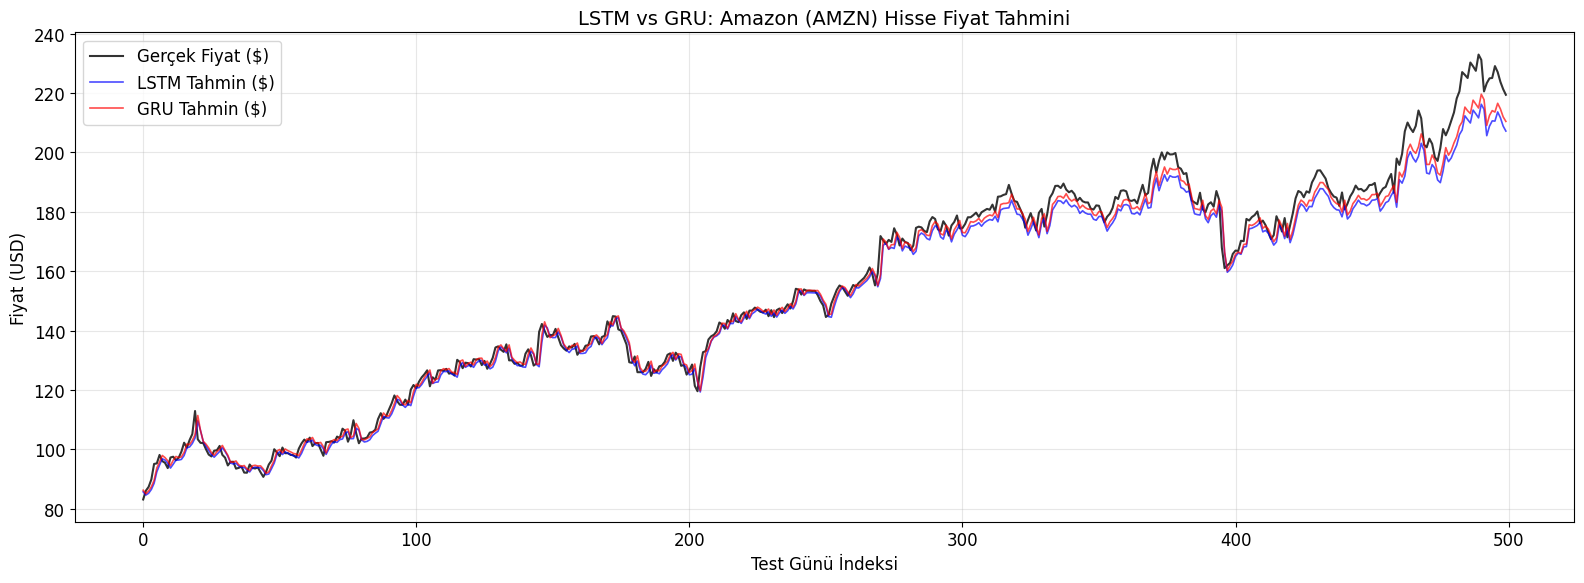

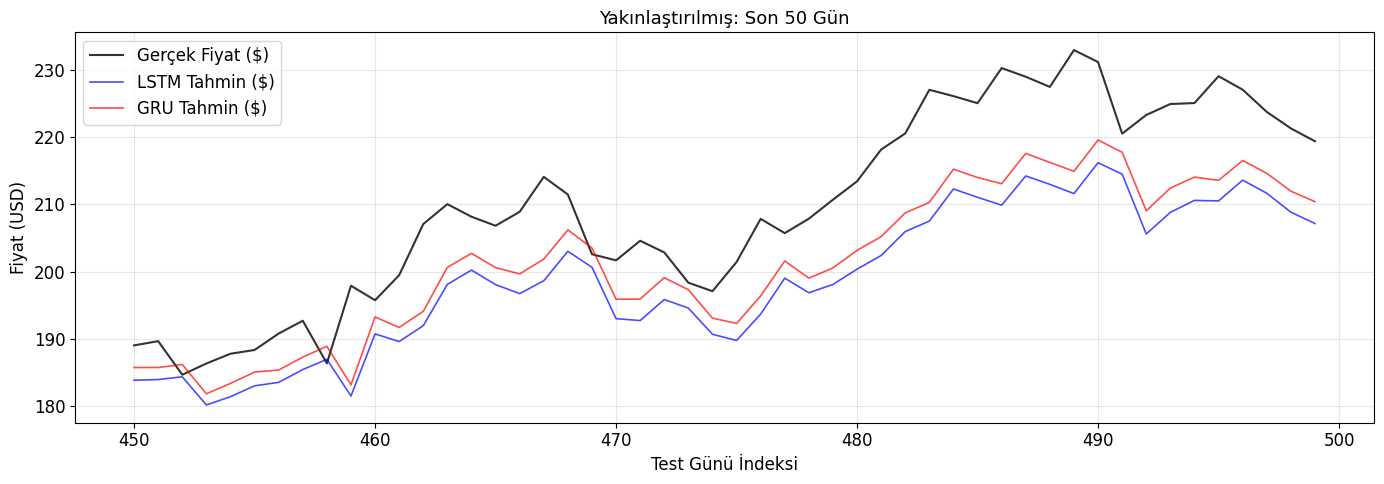

In [5]:
# Cell 2: Side-by-side plot (Real vs LSTM vs GRU predictions)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

# X eksen etiketleri (test set indeksi)
x_axis = range(len(lstm_actuals))

# Büyük grafik: Üç serinin tamamı
plt.figure(figsize=(16, 6))
plt.plot(x_axis, lstm_actuals, label='Gerçek Fiyat ($)', linewidth=1.5, alpha=0.8, color='black')
plt.plot(x_axis, lstm_preds, label='LSTM Tahmin ($)', linewidth=1.2, alpha=0.7, color='blue')
plt.plot(x_axis, gru_preds, label='GRU Tahmin ($)', linewidth=1.2, alpha=0.7, color='red')
plt.title('LSTM vs GRU: Amazon (AMZN) Hisse Fiyat Tahmini', fontsize=14)
plt.xlabel('Test Günü İndeksi')
plt.ylabel('Fiyat (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/comparison_full.png", dpi=150)
plt.show()

# Küçük grafik: Son 50 gün (yakınlaştırılmış görünüm)
plt.figure(figsize=(14, 5))
plt.plot(
    x_axis[-50:], lstm_actuals[-50:],
    label='Gerçek Fiyat ($)', linewidth=1.5, alpha=0.8, color='black',
)
plt.plot(
    x_axis[-50:], lstm_preds[-50:],
    label='LSTM Tahmin ($)', linewidth=1.2, alpha=0.7, color='blue',
)
plt.plot(
    x_axis[-50:], gru_preds[-50:],
    label='GRU Tahmin ($)', linewidth=1.2, alpha=0.7, color='red',
)
plt.title('Yakınlaştırılmış: Son 50 Gün', fontsize=13)
plt.xlabel('Test Günü İndeksi')
plt.ylabel('Fiyat (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/comparison_zoomed.png", dpi=150)
plt.show()

In [6]:
# Cell 3: Hyperparameter Improvement Suggestions

# Mevcut hiperparametreler:
#   input_size = 1 (sadece Close fiyatı)
#   hidden_size = 50
#   num_layers = 2
#   dropout = 0.2
#   lookback = 20
#   learning_rate = 0.001
#   epochs = 100

print("=" * 60)
print("📈 Hiperparametre İyileştirme Tablosu")
print("=" * 60)

improvement_table = pd.DataFrame({
    "Parametre": [
        "lookback (pencere boyutu)",
        "hidden_size (kapasite)",
        "num_layers (katman sayısı)",
        "dropout (regularization)",
        "learning_rate (öğrenme hızı)",
        "epochs (eğitim süresi)",
    ],
    "Mevcut": [
        20,
        50,
        2,
        0.2,
        0.001,
        100,
    ],
    "Önerilen Denemeler": [
        "10, 30, 50",
        "32, 64, 128",
        "1, 3",
        "0, 0.3, 0.5",
        "0.01, 0.0001",
        "50, 200",
    ],
    "Neden?": [
        "Kısa/uzun vadeli trendlerin tespiti",
        "Model kapasitesini artırma/azaltma",
        "Derinlik değişikliği",
        "Overfitting kontrolü",
        "Öğrenme hızı optimizasyonu",
        "Eğitim süresi uzatma/kısaltma",
    ],
})

print(improvement_table.to_string(index=False))

print("\n" + "=" * 60)
print("📝 İyileştirme Notları")
print("=" * 60)

print("""
1. lookback: 20 günlük pencere yerine 10 veya 50 denenebilir.
   - 10 → kısa vadeli hareketlere daha duyarlı
   - 50 → uzun vadeli trendleri daha iyi yakalar

2. hidden_size: 50'den farklı boyutlarda denenebilir.
   - Daha büyük hidden_size → daha fazla kapasite ama overfitting riski
   - Daha küçük hidden_size → daha hızlı ama eksik bilgi

3. num_layers: 2 yerine 1 veya 3 denenebilir.
   - 1 katman → daha az parametre, daha hızlı
   - 3 katman → daha derin öğrenme ama eğitim süresi artar

4. dropout: Overfitting'i önlemek için kritik.
   - 0.0 → overfitting riski yüksek
   - 0.5 → çok agresif regularization

5. learning_rate: Modelin öğrenme hızı.
   - 0.01 → hızlı öğrenme ama kaybolabilir
   - 0.0001 → yavaş ama stabil

6. epochs: Daha fazla eğitim süresi.
   - 50 → erken durma riski
   - 200 → overfitting riski artar ama daha iyi öğrenme
""")

print("🎯 Önerilen İlk Denemeler:")
print("   - hidden_size=64, num_layers=1, dropout=0.1")
print("   - Bu kombinasyon: GRU'nun %30 daha az parametresini kullanarak daha iyi sonuç verebilir")

📈 Hiperparametre İyileştirme Tablosu
                   Parametre  Mevcut Önerilen Denemeler                              Neden?
   lookback (pencere boyutu)  20.000         10, 30, 50 Kısa/uzun vadeli trendlerin tespiti
      hidden_size (kapasite)  50.000        32, 64, 128  Model kapasitesini artırma/azaltma
  num_layers (katman sayısı)   2.000               1, 3                Derinlik değişikliği
    dropout (regularization)   0.200        0, 0.3, 0.5                Overfitting kontrolü
learning_rate (öğrenme hızı)   0.001       0.01, 0.0001          Öğrenme hızı optimizasyonu
      epochs (eğitim süresi) 100.000            50, 200       Eğitim süresi uzatma/kısaltma

📝 İyileştirme Notları

1. lookback: 20 günlük pencere yerine 10 veya 50 denenebilir.
   - 10 → kısa vadeli hareketlere daha duyarlı
   - 50 → uzun vadeli trendleri daha iyi yakalar

2. hidden_size: 50'den farklı boyutlarda denenebilir.
   - Daha büyük hidden_size → daha fazla kapasite ama overfitting riski
   - Daha 

In [7]:
# Cell 4: TradingView Integration Notes

print("=" * 60)
print("🔗 TradingView Teknik İndikatör Entegrasyonu")
print("=" * 60)

# Bu kodun çalışması için tradingview_ta paketi gerekir
# pip install tradingview-ta

print("""
TradingView API'den teknik indikatörleri modelin girdisine ekleyebiliriz.

Kurulum:
    pip install tradingview-ta

Kullanım:
""")

tradingview_example = """
from tradingview_ta import TA_Handler, Interval

# TradingView'dan teknik indikatör al
handler = TA_Handler(
    symbol="AMZN",
    screener="america",
    exchange="NASDAQ",
    interval=Interval.INTERVAL_1_DAY
)

analysis = handler.get_analysis()

# İndikatörleri al
indicators = {
    'RSI': analysis.indicators['RSI'],
    'MACD': analysis.indicators['MACD.macd'],
    'SMA20': analysis.indicators['SMA20'],
    'Volume': analysis.indicators['volume'],
}

# Bunları modelin input'una ek feature olarak ekleyebiliriz
# (ileri seviye — ilk versiyonda sadece Close fiyatı kullan)
"""

print(tradingview_example)

print("=" * 60)
print("📊 Önerilen Teknik İndikatörler")
print("=" * 60)

indicators_table = pd.DataFrame({
    "İndikatör": [
        "RSI (Göreceli Güç Endeksi)",
        "MACD (Hareketli Ortalama Yakınsama/Iraksama)",
        "SMA20 (20 Günlük Basit Ortalama)",
        "EMA50 (50 Günlük Üstel Ortalama)",
        "Bollinger Bands",
        "Volume (İşlem Hacmi)",
        "Stochastic Oscillator",
    ],
    "Açıklama": [
        "0-100 arası, aşırı alım/satım bölgelerini gösterir",
        "Trend yönünü ve gücünü belirler",
        "Ortalama fiyatı gösterir, trend yönünü belirler",
        "Daha hızlı trend takibi",
        "Volatilite ve destek/direnci gösterir",
        "İşlem aktivitesi ve trend doğrulama",
        "Aşırı alım/satım ve trend dönüşü",
    ],
})

print(indicators_table.to_string(index=False))

print("\n🚀 İlerleme Önerisi:")
print("   1. İlk: Sadece Close fiyatı (mevcut model)")
print("   2. Sonra: RSI + Volume ekle (basit ama etkili)")
print("   3. İleri: Tüm indikatörleri ekle (çok boyutlu girdi)")
print("\n   Çok boyutlu girdi için models.py'de input_size=1 → input_size=7 yapılmalı")

🔗 TradingView Teknik İndikatör Entegrasyonu

TradingView API'den teknik indikatörleri modelin girdisine ekleyebiliriz.

Kurulum:
    pip install tradingview-ta

Kullanım:


from tradingview_ta import TA_Handler, Interval

# TradingView'dan teknik indikatör al
handler = TA_Handler(
    symbol="AMZN",
    screener="america",
    exchange="NASDAQ",
    interval=Interval.INTERVAL_1_DAY
)

analysis = handler.get_analysis()

# İndikatörleri al
indicators = {
    'RSI': analysis.indicators['RSI'],
    'MACD': analysis.indicators['MACD.macd'],
    'SMA20': analysis.indicators['SMA20'],
    'Volume': analysis.indicators['volume'],
}

# Bunları modelin input'una ek feature olarak ekleyebiliriz
# (ileri seviye — ilk versiyonda sadece Close fiyatı kullan)

📊 Önerilen Teknik İndikatörler
                                   İndikatör                                           Açıklama
                  RSI (Göreceli Güç Endeksi) 0-100 arası, aşırı alım/satım bölgelerini gösterir
MACD (Hareketli Ortala